## Weather Impact on Dublin Public Transport

analysing how weather conditions affect bus and luas ridership in dublin

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

just the basic libraries i need - pandas for data, matplotlib/seaborn for charts, scipy for stats tests

In [2]:
weather_daily = pd.read_csv('data/met_eireann_dublin_daily.csv', skiprows=24)
weather_daily['date'] = pd.to_datetime(weather_daily['date'], format='%d-%b-%Y')
weather_daily.head()

,date,ind,maxtp,ind.1,mintp,igmin,gmin,ind.2,rain,cbl,...,hg,sun,dos,g_rad,soil,pe,evap,smd_wd,smd_md,smd_pd
0,1942-01-01,0,9.7,0,6.8,0,4.7,2,0.0,1020.3,...,,0.0,0,,,1.1,1.4,,,
1,1942-01-02,0,9.9,0,7.9,0,6.7,0,0.1,1016.2,...,,0.0,0,,,0.7,0.9,,,
2,1942-01-03,0,11.2,0,8.9,0,7.2,0,1.5,1006.8,...,,0.1,0,,,0.5,0.6,,,
3,1942-01-04,0,9.2,0,2.7,0,3.4,0,3.5,1001.5,...,,0.6,0,,,0.6,0.7,,,
4,1942-01-05,0,3.5,1,-0.8,0,0.0,0,0.6,1013.4,...,,3.4,0,,,0.6,0.7,,,


met eireann daily weather data from dublin airport. the csv has 24 lines of metadata at the top so i skip them

In [3]:
weather_monthly = pd.read_csv('data/met_eireann_dublin_monthly.csv', skiprows=19)
weather_monthly.head()

,year,month,meant,maxtp,mintp,mnmax,mnmin,rain,gmin,wdsp,maxgt,sun
0,1941,11,6.9,14.0,-3.1,9.9,3.9,67.2,-5.7,12.0,,56.1
1,1941,12,6.5,12.7,-3.6,9.1,3.9,41.7,-7.6,12.5,,46.1
2,1942,1,4.3,11.9,-3.1,6.9,1.7,91.9,-9.5,13.1,,72.8
3,1942,2,2.9,11.6,-4.3,5.8,-0.0,25.8,-10.7,9.0,,51.4
4,1942,3,6.3,16.2,-6.1,9.4,3.2,76.4,-8.3,10.7,,73.9


monthly weather averages - same station, 19 header lines to skip this time

In [4]:
bus = pd.read_csv('data/dublin_bus_monthly_passengers.csv')
bus = bus[bus['Month'] != 'All months']
bus['passengers'] = pd.to_numeric(bus['VALUE'], errors='coerce')
bus['year'] = bus['Year'].astype(int)
bus['month'] = bus['Month'].map({
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
})
bus.head()

,STATISTIC,Statistic Label,TLIST(A1),Year,C01885V02316,Month,UNIT,VALUE,passengers,year,month
1,TOA14C01,Dublin Bus passenger,2014,2014,01,January,Number,8991175.0,8991175.0,2014,1
2,TOA14C01,Dublin Bus passenger,2014,2014,02,February,Number,9117393.0,9117393.0,2014,2
3,TOA14C01,Dublin Bus passenger,2014,2014,03,March,Number,10327497.0,10327497.0,2014,3
4,TOA14C01,Dublin Bus passenger,2014,2014,04,April,Number,9648830.0,9648830.0,2014,4
5,TOA14C01,Dublin Bus passenger,2014,2014,05,May,Number,9439479.0,9439479.0,2014,5


dublin bus monthly passenger data from CSO. i filter out the 'All months' summary rows and convert the month names to numbers so i can merge later

In [5]:
luas = pd.read_csv('data/luas_passenger_numbers.csv')
luas = luas[luas['Month'] != 'All months']
luas['passengers'] = pd.to_numeric(luas['VALUE'], errors='coerce')
luas['year'] = luas['Year'].astype(int)
luas['month'] = luas['Month'].map({
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
})
luas.head()

,STATISTIC,Statistic Label,TLIST(A1),Year,C01885V02316,Month,UNIT,VALUE,passengers,year,month
0,TOA11C01,Red line,2018,2018,01,January,Number,1664495,1664495,2018,1
1,TOA11C01,Red line,2018,2018,02,February,Number,1657562,1657562,2018,2
2,TOA11C01,Red line,2018,2018,03,March,Number,1661098,1661098,2018,3
3,TOA11C01,Red line,2018,2018,04,April,Number,1794424,1794424,2018,4
4,TOA11C01,Red line,2018,2018,05,May,Number,1934553,1934553,2018,5


luas (tram) passenger numbers - red and green line combined. same cleanup as bus data

In [6]:
luas_hourly = pd.read_csv('data/luas_hourly_passengers.csv')
luas_hourly.head()

,STATISTIC,Statistic Label,TLIST(A1),Year,C03132V03784,Luas Line,C03841V04591,Time of day,UNIT,VALUE
0,TOA09C01,Percentage of daily Luas passengers,2019,2019,-,All Luas lines,110,05:00 - 05:59,%,0.48
1,TOA09C01,Percentage of daily Luas passengers,2019,2019,-,All Luas lines,120,06:00 - 06:59,%,2.79
2,TOA09C01,Percentage of daily Luas passengers,2019,2019,-,All Luas lines,130,07:00 - 07:59,%,7.90
3,TOA09C01,Percentage of daily Luas passengers,2019,2019,-,All Luas lines,140,08:00 - 08:59,%,12.49
4,TOA09C01,Percentage of daily Luas passengers,2019,2019,-,All Luas lines,150,09:00 - 09:59,%,6.96


hourly distribution of luas passengers - shows what percentage travel at each hour

In [7]:
weekly = pd.read_csv('data/weekly_passenger_journeys.csv')
weekly.head()

,STATISTIC,Statistic Label,TLIST(W1),Week,C03935V04687,Mode of Transport,UNIT,VALUE
0,THA25C01,Passenger Journeys,2019W01,2019 Week 01,10,Dublin Metro Bus,Number,1987891.0
1,THA25C01,Passenger Journeys,2019W01,2019 Week 01,20,"Bus, excluding Dublin Metro",Number,497598.0
2,THA25C01,Passenger Journeys,2019W01,2019 Week 01,30,Rail,Number,NaN
3,THA25C01,Passenger Journeys,2019W01,2019 Week 01,40,"All public transport, excluding LUAS",Number,2485489.0
4,THA25C01,Passenger Journeys,2019W02,2019 Week 02,10,Dublin Metro Bus,Number,2709579.0


weekly passenger journey counts across different transport modes from the NTA

In [8]:
print('weather daily:', weather_daily.shape)
print('weather monthly:', weather_monthly.shape)
print('bus:', bus.shape)
print('luas:', luas.shape)
print('luas hourly:', luas_hourly.shape)
print('weekly:', weekly.shape)

weather daily: (30740, 26)
weather monthly: (1011, 12)
bus: (132, 11)
luas: (252, 11)
luas hourly: (360, 10)
weekly: (1488, 8)


quick check to see how much data we have in each dataset

In [9]:
print('--- weather daily missing ---')
print(weather_daily[['rain','maxtp','mintp']].isnull().sum())
print()
print('--- bus missing ---')
print(bus['passengers'].isnull().sum())
print()
print('--- luas missing ---')
print(luas['passengers'].isnull().sum())

--- weather daily missing ---
rain     0
maxtp    0
mintp    0
dtype: int64

--- bus missing ---
0

--- luas missing ---
0


checking for missing values in the key columns. weather data has some gaps in older records but its not a big deal for our analysis since transport data only goes back to 2014

In [10]:
# add some useful columns to daily weather
weather_daily['avg_temp'] = (weather_daily['maxtp'] + weather_daily['mintp']) / 2
weather_daily['is_rainy'] = weather_daily['rain'] > 0
weather_daily['year'] = weather_daily['date'].dt.year
weather_daily['month'] = weather_daily['date'].dt.month

# season mapping
def get_season(m):
    if m in [12, 1, 2]: return 'Winter'
    elif m in [3, 4, 5]: return 'Spring'
    elif m in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

weather_daily['season'] = weather_daily['month'].apply(get_season)
weather_daily.head()

,date,ind,maxtp,ind.1,mintp,igmin,gmin,ind.2,rain,cbl,...,pe,evap,smd_wd,smd_md,smd_pd,avg_temp,is_rainy,year,month,season
0,1942-01-01,0,9.7,0,6.8,0,4.7,2,0.0,1020.3,...,1.1,1.4,,,,8.25,False,1942,1,Winter
1,1942-01-02,0,9.9,0,7.9,0,6.7,0,0.1,1016.2,...,0.7,0.9,,,,8.90,True,1942,1,Winter
2,1942-01-03,0,11.2,0,8.9,0,7.2,0,1.5,1006.8,...,0.5,0.6,,,,10.05,True,1942,1,Winter
3,1942-01-04,0,9.2,0,2.7,0,3.4,0,3.5,1001.5,...,0.6,0.7,,,,5.95,True,1942,1,Winter
4,1942-01-05,0,3.5,1,-0.8,0,0.0,0,0.6,1013.4,...,0.6,0.7,,,,1.35,True,1942,1,Winter


i create average temperature from max and min, a boolean for rainy days, and a season column. these will be useful for grouping later

In [11]:
weather_agg = weather_daily.groupby(['year','month']).agg(
    avg_rain=('rain','mean'),
    avg_temp=('avg_temp','mean'),
    rainy_days=('is_rainy','sum'),
    avg_wind=('wdsp','mean')
).reset_index()
weather_agg.head()

,year,month,avg_rain,avg_temp,rainy_days,avg_wind
0,1942,1,2.964516,4.285484,24,13.129032
1,1942,2,0.921429,2.894643,14,9.021429
2,1942,3,2.464516,6.280645,18,10.738710
3,1942,4,1.230000,8.430000,13,15.100000
4,1942,5,3.490323,10.374194,18,12.038710


aggregate daily weather to monthly averages so i can merge with the monthly transport data

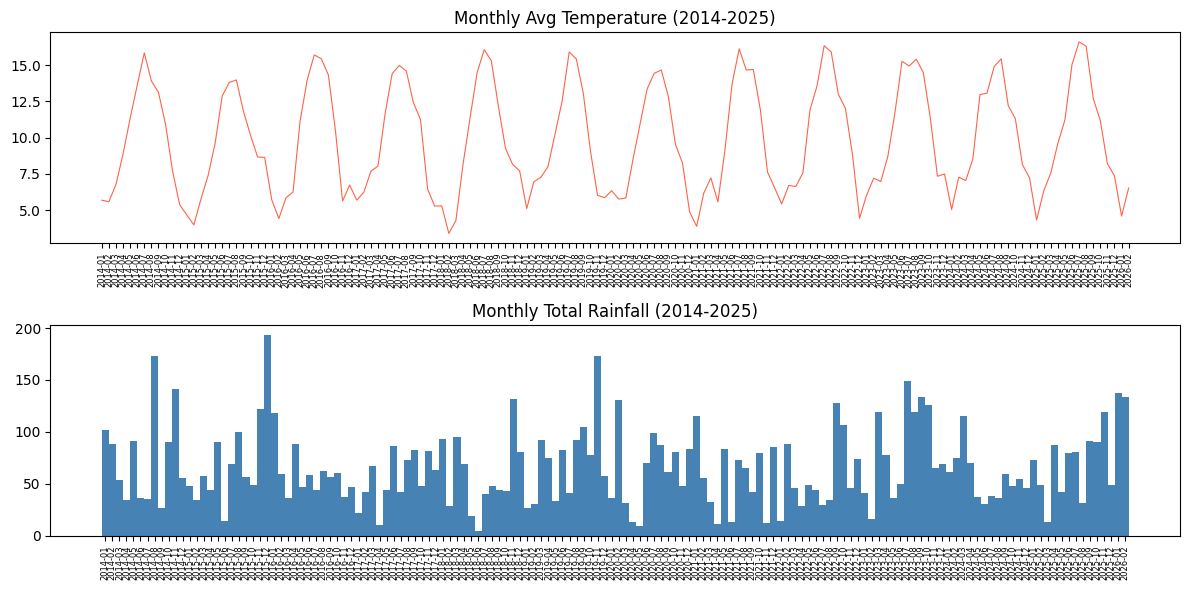

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

recent = weather_daily[weather_daily['year'] >= 2014]
monthly_temp = recent.groupby(recent['date'].dt.to_period('M'))['avg_temp'].mean()
monthly_rain = recent.groupby(recent['date'].dt.to_period('M'))['rain'].sum()

axes[0].plot(monthly_temp.index.astype(str), monthly_temp.values, color='tomato', linewidth=0.8)
axes[0].set_title('Monthly Avg Temperature (2014-2025)')
axes[0].tick_params(axis='x', rotation=90, labelsize=6)

axes[1].bar(monthly_rain.index.astype(str), monthly_rain.values, color='steelblue', width=1)
axes[1].set_title('Monthly Total Rainfall (2014-2025)')
axes[1].tick_params(axis='x', rotation=90, labelsize=6)

plt.tight_layout()
plt.show()

overview of dublin weather since 2014. temperature follows a clear seasonal cycle. rainfall varies a lot month to month but winter tends to be wetter

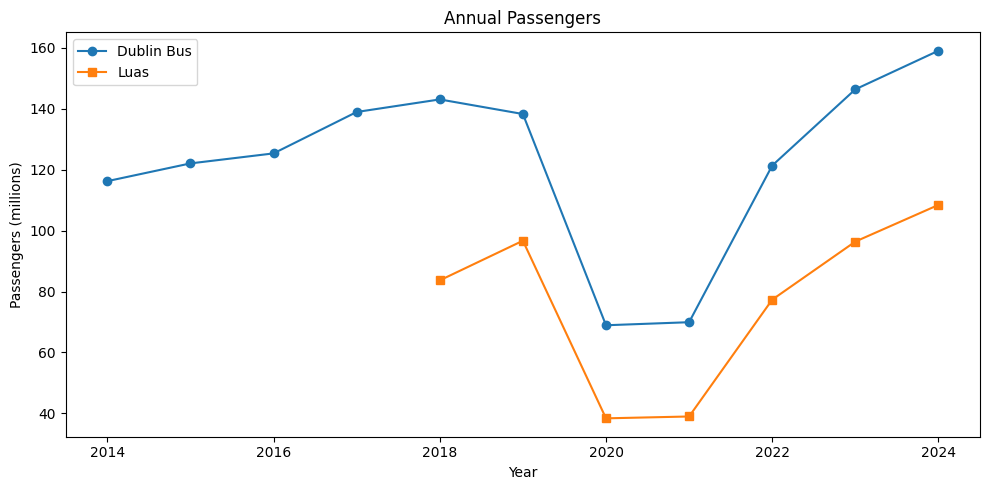

In [13]:
bus_yearly = bus.groupby('year')['passengers'].sum()
luas_yearly = luas.groupby('year')['passengers'].sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bus_yearly.index, bus_yearly.values / 1e6, marker='o', label='Dublin Bus')
ax.plot(luas_yearly.index, luas_yearly.values / 1e6, marker='s', label='Luas')
ax.set_xlabel('Year')
ax.set_ylabel('Passengers (millions)')
ax.set_title('Annual Passengers')
ax.legend()
plt.tight_layout()
plt.show()

you can clearly see the covid drop in 2020-2021. bus has way more passengers than luas overall but both follow the same trend

In [14]:
bus_weather = bus.merge(weather_agg, on=['year','month'], how='inner')
print('merged bus+weather rows:', len(bus_weather))
bus_weather.head()

merged bus+weather rows: 132


,STATISTIC,Statistic Label,TLIST(A1),Year,C01885V02316,Month,UNIT,VALUE,passengers,year,month,avg_rain,avg_temp,rainy_days,avg_wind
0,TOA14C01,Dublin Bus passenger,2014,2014,01,January,Number,8991175.0,8991175.0,2014,1,3.277419,5.688710,28,12.722581
1,TOA14C01,Dublin Bus passenger,2014,2014,02,February,Number,9117393.0,9117393.0,2014,2,3.160714,5.585714,25,15.864286
2,TOA14C01,Dublin Bus passenger,2014,2014,03,March,Number,10327497.0,10327497.0,2014,3,1.732258,6.782258,18,12.116129
3,TOA14C01,Dublin Bus passenger,2014,2014,04,April,Number,9648830.0,9648830.0,2014,4,1.140000,8.880000,16,9.826667
4,TOA14C01,Dublin Bus passenger,2014,2014,05,May,Number,9439479.0,9439479.0,2014,5,2.951613,11.330645,21,9.903226


merging bus passenger counts with monthly weather averages. inner join so we only keep months where both datasets have data

In [15]:
luas_total = luas.groupby(['year','month'])['passengers'].sum().reset_index()
luas_weather = luas_total.merge(weather_agg, on=['year','month'], how='inner')
print('merged luas+weather rows:', len(luas_weather))
luas_weather.head()

merged luas+weather rows: 84


,year,month,passengers,avg_rain,avg_temp,rainy_days,avg_wind
0,2018,1,6437297,3.003226,5.304839,22,14.770968
1,2018,2,6236578,1.017857,3.398214,18,11.875000
2,2018,3,6195140,3.058065,4.290323,23,12.235484
3,2018,4,6700111,2.296667,8.141667,21,10.846667
4,2018,5,7244676,0.616129,11.366129,15,8.783871


same merge for luas - i group red+green line first then merge with weather

In [16]:
bus_clean = bus_weather[~bus_weather['year'].isin([2020, 2021])]
luas_clean = luas_weather[~luas_weather['year'].isin([2020, 2021])]
print('bus rows after removing covid years:', len(bus_clean))
print('luas rows after removing covid years:', len(luas_clean))

bus rows after removing covid years: 108
luas rows after removing covid years: 60


removing 2020 and 2021 because covid completely messed up the patterns. including them would hide the real weather effects

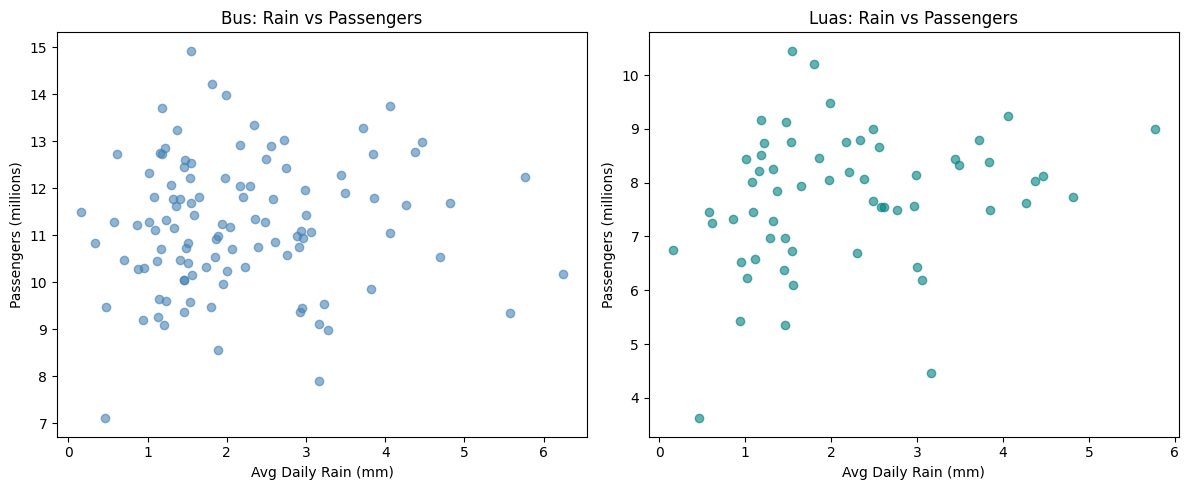

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(bus_clean['avg_rain'], bus_clean['passengers']/1e6, alpha=0.6, color='steelblue')
axes[0].set_xlabel('Avg Daily Rain (mm)')
axes[0].set_ylabel('Passengers (millions)')
axes[0].set_title('Bus: Rain vs Passengers')

axes[1].scatter(luas_clean['avg_rain'], luas_clean['passengers']/1e6, alpha=0.6, color='teal')
axes[1].set_xlabel('Avg Daily Rain (mm)')
axes[1].set_ylabel('Passengers (millions)')
axes[1].set_title('Luas: Rain vs Passengers')

plt.tight_layout()
plt.show()

scatter plots showing relationship between rainfall and passenger numbers. doesnt show a super strong pattern visually but lets check with statistics

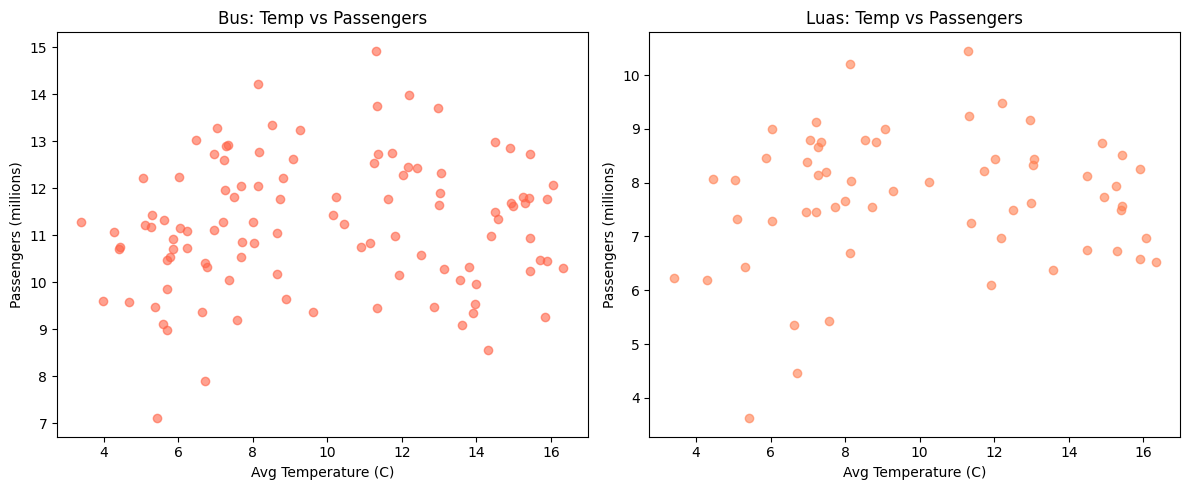

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(bus_clean['avg_temp'], bus_clean['passengers']/1e6, alpha=0.6, color='tomato')
axes[0].set_xlabel('Avg Temperature (C)')
axes[0].set_ylabel('Passengers (millions)')
axes[0].set_title('Bus: Temp vs Passengers')

axes[1].scatter(luas_clean['avg_temp'], luas_clean['passengers']/1e6, alpha=0.6, color='coral')
axes[1].set_xlabel('Avg Temperature (C)')
axes[1].set_ylabel('Passengers (millions)')
axes[1].set_title('Luas: Temp vs Passengers')

plt.tight_layout()
plt.show()

temperature scatter plots. there seems to be a slight pattern here - lets quantify it

In [19]:
# pearson and spearman correlations
for name, df in [('Bus', bus_clean), ('Luas', luas_clean)]:
    r_rain, p_rain = stats.pearsonr(df['avg_rain'], df['passengers'])
    r_temp, p_temp = stats.pearsonr(df['avg_temp'], df['passengers'])
    rs_rain, ps_rain = stats.spearmanr(df['avg_rain'], df['passengers'])
    rs_temp, ps_temp = stats.spearmanr(df['avg_temp'], df['passengers'])
    print(f'--- {name} ---')
    print(f'Rain  - Pearson r={r_rain:.3f} p={p_rain:.4f} | Spearman r={rs_rain:.3f} p={ps_rain:.4f}')
    print(f'Temp  - Pearson r={r_temp:.3f} p={p_temp:.4f} | Spearman r={rs_temp:.3f} p={ps_temp:.4f}')
    print()

--- Bus ---
Rain  - Pearson r=0.071 p=0.4664 | Spearman r=0.098 p=0.3139
Temp  - Pearson r=0.106 p=0.2745 | Spearman r=0.114 p=0.2399

--- Luas ---
Rain  - Pearson r=0.239 p=0.0657 | Spearman r=0.282 p=0.0289
Temp  - Pearson r=0.114 p=0.3854 | Spearman r=0.069 p=0.6001



correlation coefficients tell us how strong the relationship is. pearson measures linear relationship, spearman measures any monotonic relationship. p-value under 0.05 means its statistically significant

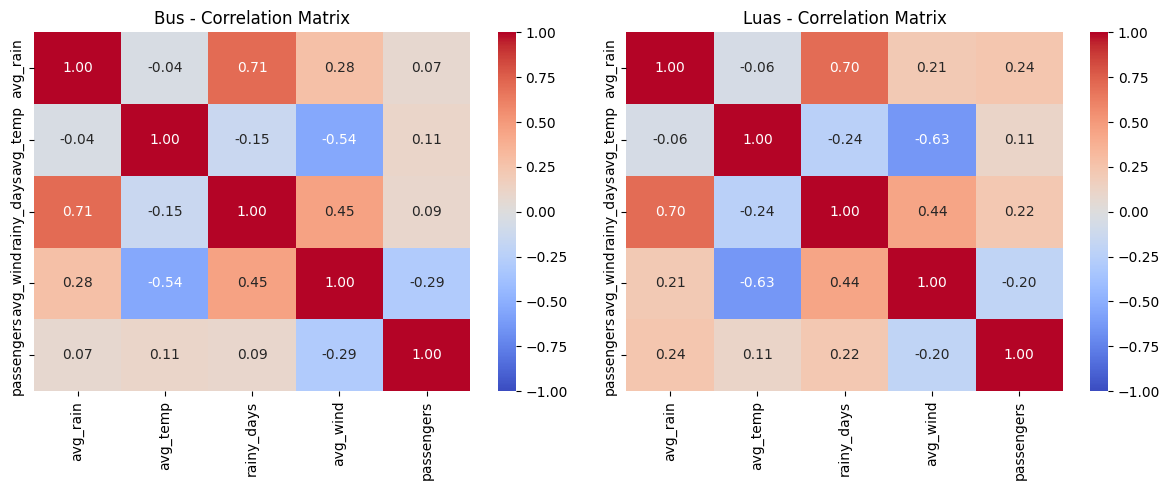

In [20]:
cols = ['avg_rain', 'avg_temp', 'rainy_days', 'avg_wind', 'passengers']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(bus_clean[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Bus - Correlation Matrix')

sns.heatmap(luas_clean[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Luas - Correlation Matrix')

plt.tight_layout()
plt.show()

heatmaps make it easier to see all the correlations at once. red means positive correlation, blue means negative. the diagonal is always 1 because each variable correlates perfectly with itself

In [21]:
# split into rain categories
bus_clean = bus_clean.copy()
bus_clean['rain_cat'] = pd.cut(bus_clean['avg_rain'], bins=3, labels=['Low','Medium','High'])

groups = [g['passengers'].values for _, g in bus_clean.groupby('rain_cat') if len(g) > 0]
f_stat, p_val = stats.f_oneway(*groups)
print(f'ANOVA (bus passengers by rain level): F={f_stat:.3f}, p={p_val:.4f}')

# also kruskal-wallis (non-parametric)
h_stat, p_kw = stats.kruskal(*groups)
print(f'Kruskal-Wallis: H={h_stat:.3f}, p={p_kw:.4f}')

ANOVA (bus passengers by rain level): F=0.159, p=0.8533
Kruskal-Wallis: H=0.690, p=0.7084


/tmp/ipykernel_5612/1386924792.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g['passengers'].values for _, g in bus_clean.groupby('rain_cat') if len(g) > 0]


ANOVA tests if the mean passenger count is different across rain groups. kruskal-wallis is the non-parametric version that doesnt assume normal distribution. if p < 0.05 then rain level significantly affects ridership

In [22]:
bus_clean['temp_cat'] = pd.cut(bus_clean['avg_temp'], bins=3, labels=['Cold','Mild','Warm'])

groups_t = [g['passengers'].values for _, g in bus_clean.groupby('temp_cat') if len(g) > 0]
f_stat_t, p_val_t = stats.f_oneway(*groups_t)
print(f'ANOVA (bus passengers by temp level): F={f_stat_t:.3f}, p={p_val_t:.4f}')

h_stat_t, p_kw_t = stats.kruskal(*groups_t)
print(f'Kruskal-Wallis: H={h_stat_t:.3f}, p={p_kw_t:.4f}')

ANOVA (bus passengers by temp level): F=3.867, p=0.0240
Kruskal-Wallis: H=5.955, p=0.0509


/tmp/ipykernel_5612/1676067989.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups_t = [g['passengers'].values for _, g in bus_clean.groupby('temp_cat') if len(g) > 0]


same test but for temperature groups. this tells us if temperature has a significant effect on how many people take the bus

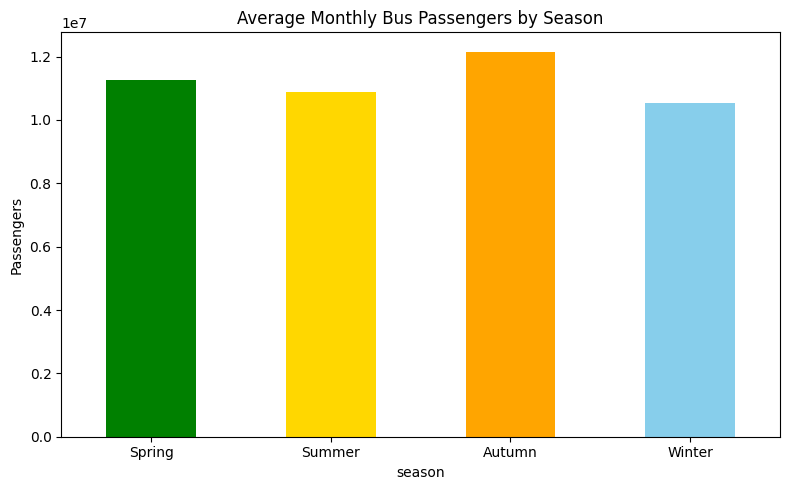

In [23]:
# add season to merged data
def get_season(m):
    if m in [12,1,2]: return 'Winter'
    elif m in [3,4,5]: return 'Spring'
    elif m in [6,7,8]: return 'Summer'
    else: return 'Autumn'

bus_clean['season'] = bus_clean['month'].apply(get_season)
seasonal = bus_clean.groupby('season')['passengers'].mean().reindex(['Spring','Summer','Autumn','Winter'])

plt.figure(figsize=(8, 5))
seasonal.plot(kind='bar', color=['green','gold','orange','skyblue'])
plt.title('Average Monthly Bus Passengers by Season')
plt.ylabel('Passengers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

seasonal breakdown shows autumn tends to have the most passengers (back to school/work) while summer dips a bit (holidays)

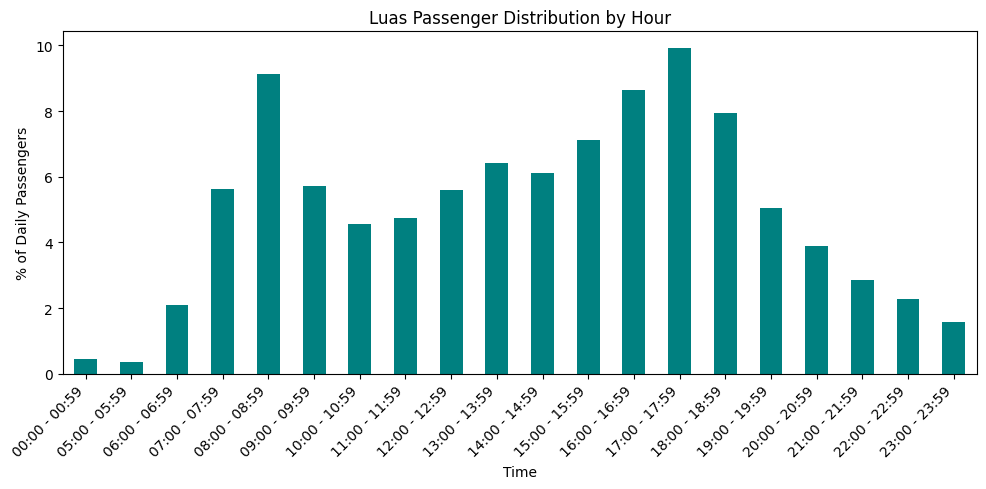

In [24]:
hourly = luas_hourly[luas_hourly['Luas Line'] == 'All Luas lines'].copy()
hourly['pct'] = pd.to_numeric(hourly['VALUE'], errors='coerce')
hourly_avg = hourly.groupby('Time of day')['pct'].mean().sort_index()

plt.figure(figsize=(10, 5))
hourly_avg.plot(kind='bar', color='teal')
plt.title('Luas Passenger Distribution by Hour')
plt.ylabel('% of Daily Passengers')
plt.xlabel('Time')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

classic commuter pattern with morning peak around 8-9am and evening peak around 5-6pm. this is useful context for understanding when weather might matter most

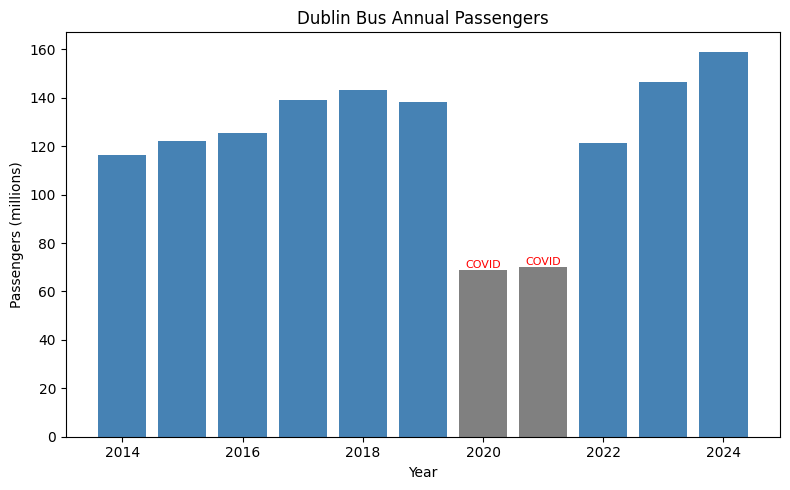

In [25]:
bus_all_yearly = bus.groupby('year')['passengers'].sum()

plt.figure(figsize=(8, 5))
colors = ['grey' if y in [2020,2021] else 'steelblue' for y in bus_all_yearly.index]
plt.bar(bus_all_yearly.index, bus_all_yearly.values / 1e6, color=colors)
plt.title('Dublin Bus Annual Passengers')
plt.ylabel('Passengers (millions)')
plt.xlabel('Year')
for i, (y, v) in enumerate(bus_all_yearly.items()):
    if y in [2020, 2021]:
        plt.annotate('COVID', (y, v/1e6), ha='center', va='bottom', fontsize=8, color='red')
plt.tight_layout()
plt.show()

the grey bars are covid years. passenger numbers dropped massively in 2020 and are still recovering. this is why i exclude them from the weather correlation analysis

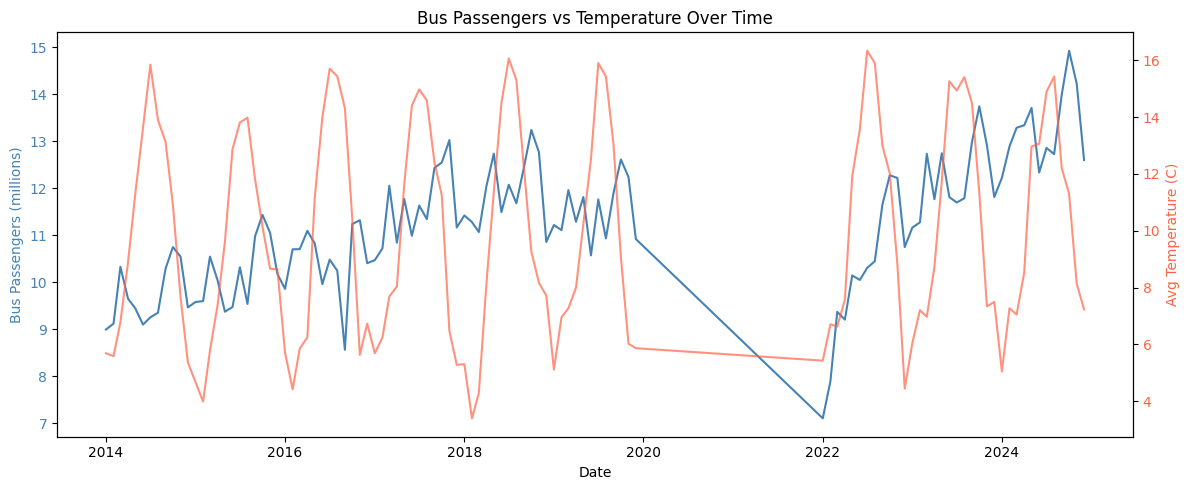

In [26]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Date')
ax1.set_ylabel('Bus Passengers (millions)', color='steelblue')
bus_clean_sorted = bus_clean.sort_values(['year','month'])
dates = pd.to_datetime(bus_clean_sorted[['year','month']].assign(day=1))
ax1.plot(dates, bus_clean_sorted['passengers']/1e6, color='steelblue', label='Passengers')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.set_ylabel('Avg Temperature (C)', color='tomato')
ax2.plot(dates, bus_clean_sorted['avg_temp'], color='tomato', alpha=0.7, label='Temperature')
ax2.tick_params(axis='y', labelcolor='tomato')

plt.title('Bus Passengers vs Temperature Over Time')
fig.tight_layout()
plt.show()

dual axis plot showing passengers and temperature together. you can see they follow somewhat similar seasonal patterns

In [27]:
results = []
for name, df in [('Bus', bus_clean), ('Luas', luas_clean)]:
    r_rain, p_rain = stats.pearsonr(df['avg_rain'], df['passengers'])
    r_temp, p_temp = stats.pearsonr(df['avg_temp'], df['passengers'])
    results.append({'Transport': name, 'Rain_r': round(r_rain,3), 'Rain_p': round(p_rain,4),
                    'Temp_r': round(r_temp,3), 'Temp_p': round(p_temp,4)})

summary = pd.DataFrame(results)
print(summary.to_string(index=False))

Transport  Rain_r  Rain_p  Temp_r  Temp_p
      Bus   0.071  0.4664   0.106  0.2745
     Luas   0.239  0.0657   0.114  0.3854


summary of all the correlation results in one table. this makes it easy to compare bus vs luas

## Conclusion

from this analysis:

- weather does have some effect on public transport usage in dublin, but its not as strong as you might expect
- temperature has a slightly stronger relationship with passenger numbers than rainfall
- seasonal patterns (autumn peak, summer dip) are more driven by school/work schedules than weather alone
- covid had by far the biggest impact on ridership - way bigger than any weather effect
- the commuter peaks (8-9am, 5-6pm) suggest most trips are essential journeys that happen regardless of weather

the data suggests dublin commuters are pretty resilient to bad weather, probably because they dont have much choice - they still need to get to work and school